## Loading the data

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("global_supply_chain_risk_2026.csv")

## Data Exploration

In [ ]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days
0,SC-10000,16-10-2025,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,42
1,SC-10001,24-04-2024,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,41
2,SC-10002,26-01-2024,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,12
3,SC-10003,08-10-2024,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,54
4,SC-10004,07-09-2024,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,1


In [ ]:
df.shape

(5000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage:

In [ ]:
#find if null values present
df.isnull().sum()

,0
Shipment_ID,0
Date,0
Origin_Port,0
Destination_Port,0
Transport_Mode,0
Product_Category,0
Distance_km,0
Weight_MT,0
Fuel_Price_Index,0
Geopolitical_Risk_Score,0


In [ ]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.84100
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.41048
min,500.170000,1.030000,1.200000,0.000000,0.500000,1.00000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,3.00000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,9.00000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,22.00000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,237.00000


In [ ]:
#find any duplicate rows
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [ ]:
#convert Date column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

#create a new feature Month
df['Month'] = df['Date'].dt.month

/tmp/ipykernel_909/4187706877.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


## Feature Selection

In [ ]:
# Target Variable
y = df['Lead_Time_Days']

In [ ]:
# Independent Variables
X = df.drop(
    columns=['Lead_Time_Days',
             'Shipment_ID',
             'Date']
)

In [ ]:
#final set of features to train the model
X.columns

Index(['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category',
       'Distance_km', 'Weight_MT', 'Fuel_Price_Index',
       'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Month'],
      dtype='object')

## One Hot Encoding

In [ ]:
X = pd.get_dummies(X, drop_first=True)

#It will automatically identify all object/category columns and one-hot encode them
#and leave the numeric columns unchanged.

In [ ]:
# snapshot of data after one-hot encoding.

X.head()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Month,Origin_Port_Busan,Origin_Port_Dubai,Origin_Port_Hamburg,Origin_Port_Los Angeles,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
0,5930.83,197.42,2.43,5.0,0.865,10,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,14285.36,237.24,2.30,7.5,0.592,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,11113.91,427.42,1.78,5.6,0.673,1,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,9180.55,170.66,3.20,0.8,0.832,10,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,2762.27,434.96,2.77,1.9,0.741,9,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False


## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

By setting random_state = 42, we're telling Python:

Use the same random pattern every time this code runs.

This means that if I run the notebook today, tomorrow, or next week, I'll get the same train-test split and the same results.

This makes it easier to reproduce our work and compare models fairly

## Model Building

### Linear Regression

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
#make predictions
pred_lr = lr.predict(X_test)

### Evaluate Model Performance - Linear Regression Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae_lr = mean_absolute_error(y_test, pred_lr)
mae_lr

12.061765079377754

In [ ]:
rmse_lr = mean_squared_error(y_test,pred_lr) ** 0.5
rmse_lr

18.65314091814975

In [ ]:
r2_lr = r2_score(y_test,pred_lr)
r2_lr

0.6144995031495528

### Sanity Check Predictions

In [ ]:
pred_lr

array([ 2.88454892e+01,  6.03354915e+01,  2.38524646e+01,  5.68716968e+00,
        1.04481183e+01,  1.99727663e+01,  2.02025038e+01,  4.39117019e+01,
       -1.11994242e+01, -3.86738502e+00,  8.08361081e+00,  3.87211284e+01,
        7.75449342e+00, -1.07081430e+01, -1.26584668e+01,  1.66398985e+01,
       -2.20552320e+01,  2.87473155e+01,  4.32825615e+00,  2.32326707e+01,
        6.37050754e+01,  2.40812530e+00,  2.06002869e+01, -4.30653085e+00,
       -1.03220201e+01, -7.60748650e+00, -1.56505800e+01,  2.10016283e+01,
        4.06523002e+01, -2.44930062e+01,  2.59272198e+01,  6.88224478e+01,
       -1.32144925e+01,  4.55141602e+01,  6.68164428e+01,  2.59810827e+01,
       -2.62208762e+00,  5.69127872e-01,  5.28250427e+01,  2.26806230e+01,
       -4.48933135e+00,  7.09563668e+01, -2.81436007e+01,  4.61760860e+01,
        4.37224425e+01,  5.67956945e+01,  4.05507256e+01,  4.59254660e+01,
       -7.14727453e+00,  5.04220374e+01, -3.51954117e-01,  1.06291876e+01,
        3.85650216e+01,  

In [ ]:
import numpy as np
np.sum(pred_lr < 0)

np.int64(231)

<Axes: xlabel='Lead_Time_Days', ylabel='Count'>

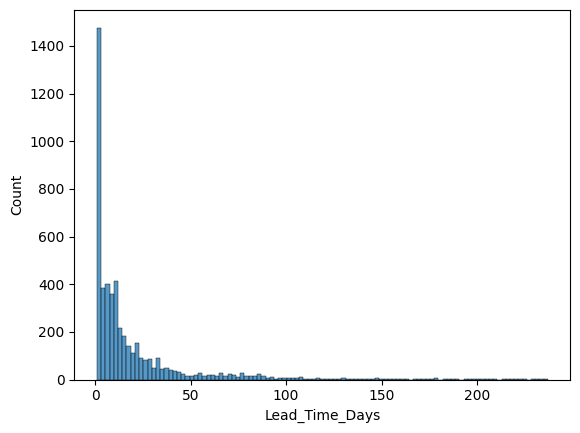

In [ ]:
#distribution of lead_time_days
import seaborn as sns
sns.histplot(df['Lead_Time_Days'])

In [ ]:
#Clip predictions in pred_lr which are negative. Clip them to 1
pred_lr_clipped = np.clip(pred_lr, a_min=1, a_max=None)

In [ ]:
pred_lr_clipped

array([28.84548918, 60.33549153, 23.85246461,  5.68716968, 10.44811831,
       19.97276626, 20.20250379, 43.91170193,  1.        ,  1.        ,
        8.08361081, 38.72112838,  7.75449342,  1.        ,  1.        ,
       16.6398985 ,  1.        , 28.74731549,  4.32825615, 23.23267069,
       63.70507538,  2.4081253 , 20.60028688,  1.        ,  1.        ,
        1.        ,  1.        , 21.00162827, 40.65230017,  1.        ,
       25.92721981, 68.82244783,  1.        , 45.51416016, 66.8164428 ,
       25.98108266,  1.        ,  1.        , 52.82504272, 22.68062296,
        1.        , 70.9563668 ,  1.        , 46.17608604, 43.72244252,
       56.79569448, 40.55072565, 45.92546596,  1.        , 50.42203742,
        1.        , 10.62918758, 38.56502156, 31.4844266 , 18.98444753,
        1.        , 18.45786716,  1.        , 27.75580319,  7.45490478,
       61.0911255 ,  4.11522164,  1.        , 26.9145676 , 35.13297279,
        1.        , 22.24370444,  1.        , 29.82160879, 45.14

### Decision Tree Model

In [ ]:
# Model 2: Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42,max_depth=5)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
#predictions using decision tree model
pred_dt = dt.predict(X_test)

In [ ]:
# Sanity Check Predictions
np.sum(pred_dt < 0)

np.int64(0)

### Evaluate Model Performance - Decision Tree Model

In [ ]:
mae_dt = mean_absolute_error(y_test, pred_dt)
mae_dt

5.112752996006828

In [ ]:
rmse_dt = mean_squared_error(y_test,pred_dt) ** 0.5
rmse_dt

7.516253105661075

In [ ]:
r2_dt = r2_score(y_test, pred_dt)
r2_dt

0.9374072846280206

## Feature Importance

In [ ]:
#feature importance of decision tree model
importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": dt.feature_importances_
    }
)

importance.sort_values(
    by="Importance",
    ascending=False
).head(5)

,Feature,Importance
29,Weather_Condition_Hurricane,0.310448
23,Transport_Mode_Sea,0.282065
0,Distance_km,0.268864
22,Transport_Mode_Road,0.050281
21,Transport_Mode_Rail,0.043519
